In [2]:
import os, pickle

import sys
sys.path.insert(1, '..')

from physics.simulation import msq, sample
from physics.hzz import zpair, zz4l
from alice import dataset, model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist

import torch
from lightning import Trainer

In [58]:
OUTPUT_DIR = '../jobs/alice/refactor-one-500k'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

CHECKPOINT = 'checkpoint-alice-epoch=54-val_loss=0.47.ckpt'

VERSION = 1
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

COMPONENT_2 = msq.Component.BKG
COMPONENT_1 = msq.Component.SIG

SAMPLE_SIZE = 250000

train_val = False

BATCH_SIZE = 256
SEED = 42

In [59]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

In [65]:
'''training_data = dataset.AliceDataModule(data_dir=SAMPLE_DIR,
                                        background_file=filenames[COMPONENT_2],
                                        background_xs=xs[COMPONENT_2],
                                        signal_component=COMPONENT_1,
                                        background_component=COMPONENT_2,
                                        scaler_path=os.path.join(OUTPUT_DIR, SCALER_FILE),
                                        sample_size=SAMPLE_SIZE,
                                        batch_size=BATCH_SIZE,
                                        random_state=SEED)

validation_data = dataset.AliceDataModule(data_dir=SAMPLE_DIR,
                                          background_file=filenames[COMPONENT_2],
                                          background_xs=xs[COMPONENT_2],
                                          signal_component=COMPONENT_1,
                                          background_component=COMPONENT_2,
                                          scaler_path=os.path.join(OUTPUT_DIR, SCALER_FILE),
                                          sample_size=SAMPLE_SIZE,
                                          offset=SAMPLE_SIZE,
                                          batch_size=BATCH_SIZE,
                                          random_state=SEED) if train_val else None'''

In [60]:
loaded_model = model.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [61]:
sample_background = sample.from_csv(cross_section=xs[COMPONENT_2], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_2]), n_rows=int(SAMPLE_SIZE*1.2)).reweight(COMPONENT_2,COMPONENT_1)

msq_bkg_null = msq.MSQFilter('msq_bkg_sm', 0.0)

z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

sample_processed = sample_background.filter(msq_bkg_null).calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

X = sample_processed.kinematics[features].to_numpy()

with open(os.path.join(OUTPUT_DIR, SCALER_FILE), 'rb') as f:
    scaler = pickle.load(f)

X_scaled = scaler.transform(X)

1.683692811355887


In [62]:
predictions = loaded_model(torch.tensor(X_scaled, dtype=torch.float32)).detach().view(-1).numpy()

In [63]:
predictions_train = predictions

ratios = sample_processed.probabilities/sample_processed.reweight(COMPONENT_1, COMPONENT_2).probabilities
targets_train = ratios/(1+ratios)

weights_train = (sample_processed.probabilities + sample_processed.reweight(COMPONENT_1, COMPONENT_2).probabilities)/2*len(sample_processed.probabilities)

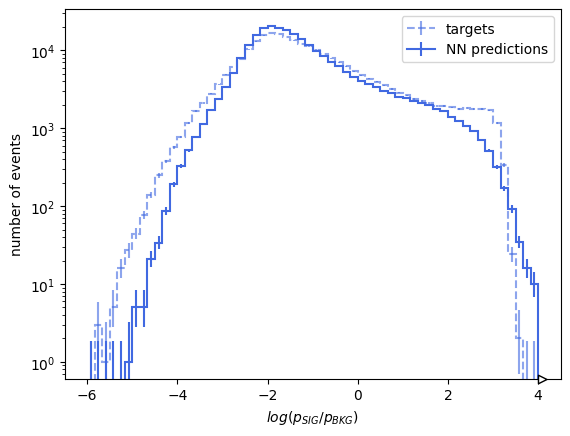

In [64]:
BINS = 60

bounds = [-6,4]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(np.log(predictions_train/(1-predictions_train)))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(np.log(targets_train/(1-targets_train)))


if train_val:
    h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
    h_predictions_val.fill(np.log(predictions_val/(1-predictions_val)))

    h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
    h_targets_val.fill(np.log(targets_val/(1-targets_val)))

    h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
    h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')

    bin_edges = h_predictions_val.axes[0].edges
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_heights = h_predictions_val.values()

    h_targets_val.plot(color='red', linestyle='--', label='targets (validation)', alpha=0.6)
    plt.scatter(bin_centers, bin_heights, color='red', marker='o', s=20, label='NN predictions (validation)')
else:
    h_targets_train.plot(color='royalblue', linestyle='--', label='targets', alpha=0.6)
    h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions')

plt.xlabel('$log(p_{SIG}/p_{BKG})$')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

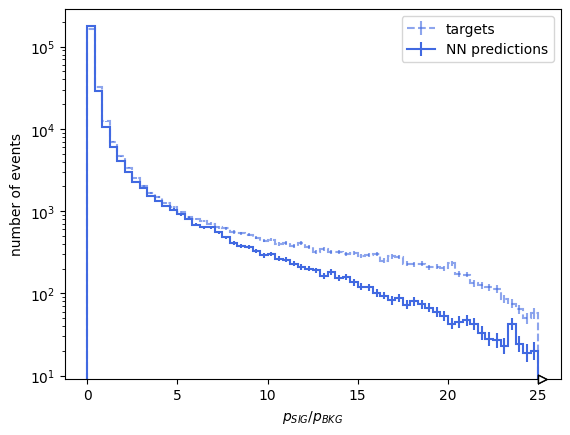

In [65]:
BINS = 60

bounds = [0,25]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(predictions_train/(1-predictions_train))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(targets_train/(1-targets_train))

if train_val:
    h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
    h_predictions_val.fill(predictions_val/(1-predictions_val))

    h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
    h_targets_val.fill(targets_val/(1-targets_val))

    h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
    h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')

    bin_edges = h_predictions_val.axes[0].edges
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_heights = h_predictions_val.values()

    h_targets_val.plot(color='red', linestyle='--', label='targets (validation)', alpha=0.6)
    plt.scatter(bin_centers, bin_heights, color='red', marker='o', s=20, label='NN predictions (validation)')
else:
    h_targets_train.plot(color='royalblue', linestyle='--', label='targets', alpha=0.6)
    h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions')

plt.xlabel('$p_{SIG}/p_{BKG}$')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

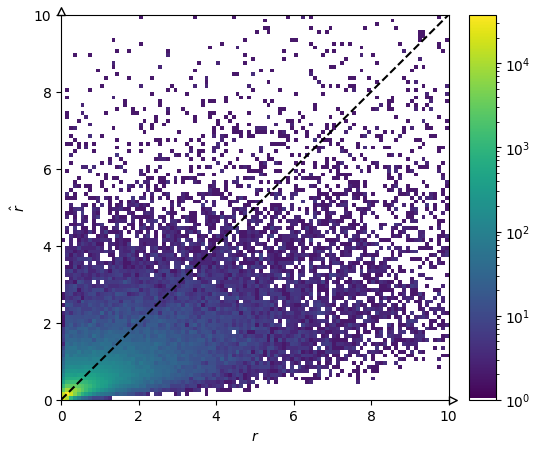

In [70]:
BINS=100

bounds = [0,10]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='$r$'),
    hist.axis.Regular(BINS, *bounds, name='$\hat{r}$')
)

h_calibration_train.fill(targets_train/(1-targets_train), predictions_train/(1-predictions_train))

if train_val:
    h_calibration_val = hist.Hist(
        hist.axis.Regular(BINS, *bounds, name='$log(r)$'),
        hist.axis.Regular(BINS, *bounds, name='$log(\hat{r})$')
    )

    h_calibration_val.fill(np.log(targets_val/(1-targets_val)), np.log(predictions_val/(1-predictions_val)))

    cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))

    h_calibration_train.plot2d(ax=ax1, cmap=cmap, cbar=False, norm=LogNorm())
    ax1.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

    ax1.set_title('training data')

    h_calibration_val.plot2d(ax=ax2, cmap=cmap, norm=LogNorm())
    ax2.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

    ax2.set_title('validation data')

    plt.show()
else:
    cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

    fig = plt.figure(figsize=(5,5))

    h_calibration_train.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
    plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

    plt.show()

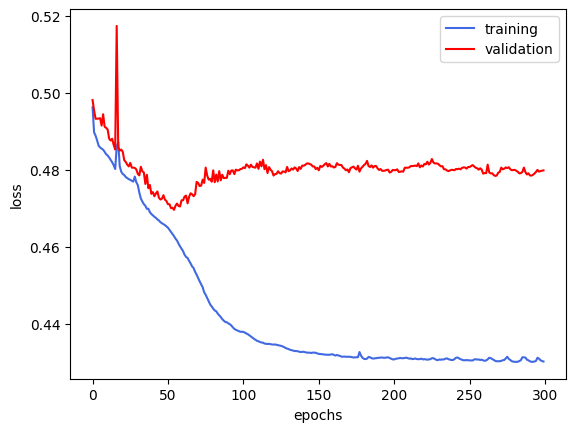

In [73]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()